# Decision Tree (درخت تصمیم)

**Decision Tree** یا **درخت تصمیم** یکی از الگوریتم‌های محبوب یادگیری ماشین برای حل مسائل **Classification** و **Regression** است.

ایده‌ی اصلی این الگوریتم بسیار ساده است: مدل با ایجاد مجموعه‌ای از **سؤال‌ها و شرط‌ها**، داده‌ها را به گروه‌های مختلف تقسیم می‌کند تا در نهایت به یک نتیجه برسد.

برای مثال، در پروژه Titanic می‌توانیم چنین تصمیم‌هایی داشته باشیم:

```text
آیا مسافر زن است؟
       │
   ┌───┴───┐
  بله      خیر
   │        │
زنده؟    آیا کلاس 1 است؟
            │
         ┌──┴──┐
        بله    خیر
```

مدل این تصمیم‌ها را از روی داده‌های آموزشی یاد می‌گیرد.

## الگوریتم Decision Tree چگونه کار می‌کند؟

درخت تصمیم از یک نقطه شروع می‌شود که به آن **Root Node** گفته می‌شود.

سپس الگوریتم ویژگی‌های مختلف را بررسی می‌کند و سعی می‌کند بهترین ویژگی را برای تقسیم داده‌ها پیدا کند.

به هر تقسیم، یک **Split** گفته می‌شود.

فرآیند کلی به شکل زیر است:

```text
داده‌های آموزشی
      ↓
انتخاب بهترین ویژگی
      ↓
تقسیم داده‌ها
      ↓
انتخاب بهترین ویژگی برای هر بخش
      ↓
تقسیم مجدد
      ↓
رسیدن به Leaf Node
      ↓
پیش‌بینی
```

### انتخاب بهترین تقسیم

برای انتخاب بهترین تقسیم، Decision Tree از معیارهایی برای اندازه‌گیری کیفیت تقسیم استفاده می‌کند.

در مسائل Classification معیارهایی مانند:

* **Gini Impurity**
* **Entropy**

استفاده می‌شوند.

هدف این است که داده‌ها به شکلی تقسیم شوند که نمونه‌های هر گروه تا حد ممکن **همگن** باشند.

برای مثال، اگر یک شاخه تقریباً تماماً شامل مسافران زنده‌مانده باشد، تقسیم مناسبی محسوب می‌شود.

### Leaf Node چیست؟

آخرین قسمت‌های درخت را **Leaf Node** یا برگ می‌نامیم.

در Classification، برگ معمولاً مشخص می‌کند که نمونه متعلق به کدام کلاس است.

در پروژه Titanic:

```text
0 → فوت شده
1 → زنده مانده
```

بنابراین مدل با عبور یک مسافر از مسیرهای مختلف درخت، در نهایت به یکی از این کلاس‌ها می‌رسد.

## مزیت Decision Tree

یکی از مهم‌ترین مزایای Decision Tree این است که ساختار آن نسبتاً قابل فهم است و می‌توان تصمیم‌های مدل را به شکل یک درخت مشاهده کرد.

همچنین این الگوریتم معمولاً به **Scaling ویژگی‌ها** مانند Standardization نیاز ندارد.

## نکته مهم

اگر درخت بیش از حد رشد کند، ممکن است مدل داده‌های آموزشی را بیش از حد یاد بگیرد. به این مشکل **Overfitting** گفته می‌شود.

یکی از راه‌های کنترل آن تعیین پارامترهایی مانند:

```python
max_depth
```

است.

در این پروژه برای ساده و کنترل‌شده بودن مدل، از یک `max_depth` مشخص استفاده می‌کنیم.


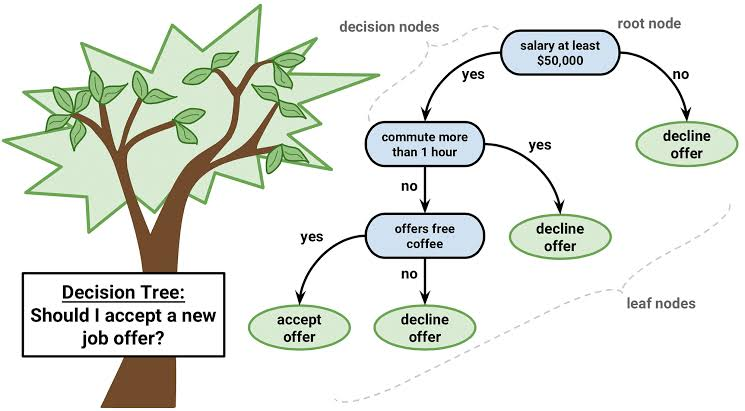

### Import Libararies

پیدا کردن دیتا
بررسی و پاکسازی دیتا
دیتا رو به داده های آموزشی و آزمایشی تقسیم کردن
مدل سازی
تست مدل

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### Read Data

In [2]:
df = pd.read_csv("titanic.csv")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Selecting features and targets

In [3]:
features = ["pclass", "sex", "age"]

X = df[features]
y = df["survived"]
X

,pclass,sex,age
0,3,male,22.0
1,1,female,38.0
2,3,female,26.0
3,1,female,35.0
4,3,male,35.0
...,...,...,...
886,2,male,27.0
887,1,female,19.0
888,3,female,NaN
889,1,male,26.0


### show by scotter plot

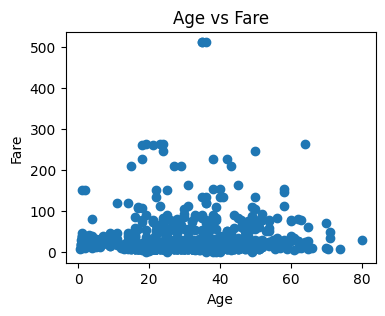

In [4]:
plt.figure(figsize=(4, 3))

plt.scatter(df["age"], df["fare"])

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare")

plt.show()

### Converting gender to a number

In [5]:
encoder = LabelEncoder()

X["sex"] = encoder.fit_transform(X["sex"])

C:\Users\kahkeshan\AppData\Local\Temp\ipykernel_7592\1657048249.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["sex"] = encoder.fit_transform(X["sex"])


### Removing incomplete data

In [6]:
X = X.dropna()

y = y[X.index]

### Split Data

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
    
)




### Modeling

In [8]:
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

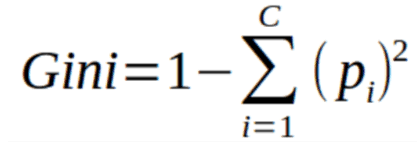

### Predcit

In [9]:
predictions = model.predict(X_test)
predictions

array([0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1])

## Model Evaluation

#### Accuracy

In [10]:
# Check model accyracy
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.7482517482517482


#### Percision

### نکته: Precision به ما می‌گوید از بین افرادی که مدل پیش‌بینی کرده زنده می‌مانند (1)، چند درصد واقعاً زنده مانده‌اند.

In [11]:
# check model percision

percision = precision_score(y_test, predictions)
print('Percision:', percision)

Percision: 0.7083333333333334


#### Recall

### نکته: Recall به ما می‌گوید از بین افرادی که واقعاً زنده مانده‌اند (1)، مدل چند درصد را درست شناسایی کرده است.

In [12]:
# checl model recall

recall = recall_score(y_test, predictions)
print('Recall:', recall)

Recall: 0.6071428571428571


#### F1 score

### F1 Score ترکیبی از Precision و Recall است و زمانی مفید است که بخواهیم بین این دو معیار تعادل برقرار کنیم.

In [13]:
# check model F1 score

f1 = f1_score(y_test, predictions)
print('F1 score:', f1)

F1 score: 0.6538461538461539


## Check Generalization

In [14]:
# check over and under fitting

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.8266199649737302
Test Accuracy: 0.7482517482517482


#### Generalization Gap

In [15]:
# check Generalization Gap

generalization_gap = train_accuracy - test_accuracy

print(f"Generalization Gap: {generalization_gap:.2f}")

Generalization Gap: 0.08


## بررسی Generalization، Overfitting و Underfitting

در این بخش عملکرد مدل را روی داده‌های آموزشی و داده‌های تست با یکدیگر مقایسه می‌کنیم تا ببینیم مدل تا چه اندازه توانایی **Generalization** یا تعمیم به داده‌های جدید را دارد.

نتیجه مدل ما:

- **Training Accuracy:** 82.7%
- **Test Accuracy:** 74.8%
- **Generalization Gap:** حدود 7.9%

**Generalization** یعنی مدل بتواند الگوهایی را که از داده‌های آموزشی یاد گرفته است، روی داده‌های جدید و دیده‌نشده نیز به‌درستی استفاده کند.

در مدل ما، عملکرد روی داده‌های تست کمتر از داده‌های آموزشی است، اما بخش قابل توجهی از عملکرد مدل روی داده‌های جدید حفظ شده است.

اگر **Training Accuracy بسیار بالا** باشد اما **Test Accuracy به‌طور قابل توجهی پایین‌تر** باشد، می‌تواند نشانه‌ی **Overfitting** باشد. در این حالت مدل داده‌های آموزشی را بیش از حد یاد گرفته و در تعمیم دادن آموخته‌های خود به داده‌های جدید مشکل دارد.

```text
Training Accuracy → بسیار بالا
Test Accuracy     → به‌طور قابل توجهی پایین‌تر
                         ↓
                    Overfitting
                    
اگر هم Training Accuracy پایین باشد و هم Test Accuracy پایین باشد، می‌تواند نشانه‌ی Underfitting باشد. در این حالت مدل حتی نتوانسته الگوهای اصلی موجود در داده‌های آموزشی را به‌خوبی یاد بگیرد.

در پروژه‌ی فعلی، Training Accuracy برابر با 82.7% و Test Accuracy برابر با 74.8% است و Generalization Gap حدود 7.9% می‌باشد.